# System-Wide Backtest with HMM Regime Detection

This notebook backtests the entire trading system, focusing on how the Hidden Markov Model (HMM) `RegimeDetector` switches between strategies.

**Logic:**
- **Regime 0 (Calm):** Execute **Pairs Trading** (Mean Reversion).
- **Regime 1 (Volatile):** Execute **Volatility Arbitrage** (Gamma Scalping).

We will simulate both strategies over the historical period and combine their equity curves based on the detected regime.

In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging

# Add project root to path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_handler import DataHandler
from src.regime_detector import RegimeDetector
from src.strategies.volatility_arb import VolatilityArbitrageStrategy
from src.options.data_handler import OptionDataHandler
from src.options.multileg import MultiLegExecutionHelper

# Setup Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

# Configuration
START_DATE = '2010-01-01'
END_DATE = '2025-01-01'
INITIAL_CAPITAL = 100000.0
SPY_SYMBOL = 'SPY'
PAIR_SYMBOLS = ('BLK', 'MS') # Example Pair
HEDGE_RATIO = 7.91 # From cointegrated_pairs.csv

print("Libraries imported and paths set.")

Libraries imported and paths set.


2025-12-11 15:00:36,169 - src.regime_detector - INFO - RegimeDetector: Loading existing model (Age: 0 days)
2025-12-11 15:00:36,173 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)
2025-12-11 15:00:36,173 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)


Data Handler (alpaca-py) initialized.
Fetching data for SPY...
Submitting data request to Alpaca...
Predicting regimes...
Predicting regimes...


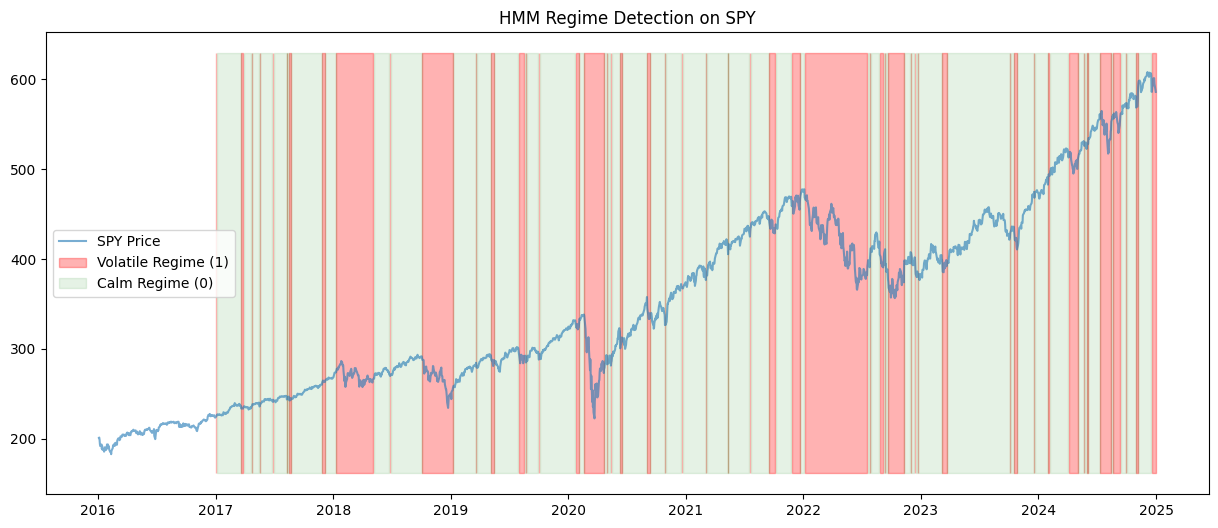

In [ ]:
# Initialize Data Handler
data_handler = DataHandler(paper_trading=True)

# Initialize Regime Detector
# We force a retrain to ensure it covers the backtest period correctly or uses pre-backtest data
regime_detector = RegimeDetector(data_handler, symbol=SPY_SYMBOL)

# Fetch Data for the Backtest Period
print(f"Fetching data for {SPY_SYMBOL}...")
spy_data = data_handler.get_historical_bars([SPY_SYMBOL], '1D', START_DATE, END_DATE)[SPY_SYMBOL]

# Predict Regimes for the Backtest Period
print("Predicting regimes...")
features = regime_detector.prepare_features(spy_data)
regimes = regime_detector.model.predict(features)

# Align Regimes with Dates
# The features DataFrame index is the date
regime_series = pd.Series(regimes, index=features.index, name='regime')

# Plot Regimes
plt.figure(figsize=(15, 6))
plt.plot(spy_data.index, spy_data['close'], label='SPY Price', alpha=0.6)
# Highlight Volatile Regimes (State 1)
y_min, y_max = plt.ylim()
plt.fill_between(regime_series.index, y_min, y_max, where=(regime_series==1), color='red', alpha=0.3, label='Volatile Regime (1)')
plt.fill_between(regime_series.index, y_min, y_max, where=(regime_series==0), color='green', alpha=0.1, label='Calm Regime (0)')
plt.title(f"HMM Regime Detection on {SPY_SYMBOL}")
plt.legend()
plt.show()

In [ ]:
# --- Strategy 1: Options Strategies (Iron Condor & Long Put) ---

class NoOpExecutionHandler:
    def submit_order(self, symbol, side, qty): pass
    def get_all_positions(self): return []
    def close_position(self, symbol): pass

class NoOpPortfolioManager:
    def check_allocation(self, strategy_id): return True

option_data_handler = OptionDataHandler(data_handler)
multi_leg_helper = MultiLegExecutionHelper(NoOpExecutionHandler())

# Leverage Configuration
# Target 2x Notional Exposure. 
# SPY ~ $400. 1 Contract = $40k. Capital = $100k. 2x = $200k.
# Contracts = 200k / 40k = 5.
LEVERAGE_CONTRACTS = 5 

# 1. Iron Condor Strategy (for Calm Regime)
iron_condor_strategy = VolatilityArbitrageStrategy(
    data_handler=data_handler,
    execution_handler=NoOpExecutionHandler(),
    portfolio_manager=NoOpPortfolioManager(),
    strategy_id=f"IronCondor_{SPY_SYMBOL}",
    symbol=SPY_SYMBOL,
    option_data_handler=option_data_handler,
    multi_leg_execution=multi_leg_helper,
    initial_capital=INITIAL_CAPITAL,
    contracts=LEVERAGE_CONTRACTS,
    strategy_type='iron_condor'
)

print("Running Iron Condor Backtest (Calm Regime Strategy)...")
ic_results = iron_condor_strategy.run_backtest(START_DATE, END_DATE, initial_capital=INITIAL_CAPITAL)
ic_equity = ic_results['equity_curve']
ic_equity['daily_return'] = ic_equity['equity'].pct_change().fillna(0)

# 2. Long Put Strategy (for Volatile Regime)
long_put_strategy = VolatilityArbitrageStrategy(
    data_handler=data_handler,
    execution_handler=NoOpExecutionHandler(),
    portfolio_manager=NoOpPortfolioManager(),
    strategy_id=f"LongPut_{SPY_SYMBOL}",
    symbol=SPY_SYMBOL,
    option_data_handler=option_data_handler,
    multi_leg_execution=multi_leg_helper,
    initial_capital=INITIAL_CAPITAL,
    contracts=LEVERAGE_CONTRACTS, # Maybe less leverage for long vol? Keeping consistent for now.
    strategy_type='long_put'
)

print("Running Long Put Backtest (Volatile Regime Strategy)...")
lp_results = long_put_strategy.run_backtest(START_DATE, END_DATE, initial_capital=INITIAL_CAPITAL)
lp_equity = lp_results['equity_curve']
lp_equity['daily_return'] = lp_equity['equity'].pct_change().fillna(0)

print(f"Iron Condor Total Return: {ic_results['return_pct']:.2f}%")
print(f"Long Put Total Return: {lp_results['return_pct']:.2f}%")

2025-12-11 15:00:37,738 - src.strategies.base_strategy - INFO - Strategy IronCondor_SPY initialized with symbols: ['SPY']
2025-12-11 15:00:37,739 - src.strategies.volatility_arb - INFO - [IronCondor_SPY] Starting Backtest (iron_condor) from 2010-01-01 to 2025-01-01...
2025-12-11 15:00:37,740 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)
2025-12-11 15:00:37,739 - src.strategies.volatility_arb - INFO - [IronCondor_SPY] Starting Backtest (iron_condor) from 2010-01-01 to 2025-01-01...
2025-12-11 15:00:37,740 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)


Running Iron Condor Backtest (Calm Regime Strategy)...
Submitting data request to Alpaca...


2025-12-11 15:00:38,336 - src.strategies.volatility_arb - INFO - [IronCondor_SPY] Backtest Complete. Total PnL: $6977.48 (6.98%)
2025-12-11 15:00:38,353 - src.strategies.base_strategy - INFO - Strategy LongPut_SPY initialized with symbols: ['SPY']
2025-12-11 15:00:38,355 - src.strategies.volatility_arb - INFO - [LongPut_SPY] Starting Backtest (long_put) from 2010-01-01 to 2025-01-01...
2025-12-11 15:00:38,355 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)
2025-12-11 15:00:38,353 - src.strategies.base_strategy - INFO - Strategy LongPut_SPY initialized with symbols: ['SPY']
2025-12-11 15:00:38,355 - src.strategies.volatility_arb - INFO - [LongPut_SPY] Starting Backtest (long_put) from 2010-01-01 to 2025-01-01...
2025-12-11 15:00:38,355 - src.data_handler - INFO - [API] Fetching historical 1D bars for 1 symbols (SPY...)


Running Long Put Backtest (Volatile Regime Strategy)...
Submitting data request to Alpaca...


2025-12-11 15:00:38,761 - src.strategies.volatility_arb - INFO - [LongPut_SPY] Backtest Complete. Total PnL: $0.00 (0.00%)


Iron Condor Total Return: 6.98%
Long Put Total Return: 0.00%


In [ ]:
# --- Strategy 3: Sector Momentum (Monthly) ---
from src.strategies.sector_momentum import SectorMomentumStrategy
from src.strategies_config import SECTOR_UNIVERSE, DEFENSIVE_ASSETS

print("Running Sector Momentum Backtest...")

# Initialize Strategy
sector_strategy = SectorMomentumStrategy(
    data_handler=data_handler,
    execution_handler=NoOpExecutionHandler(),
    portfolio_manager=NoOpPortfolioManager(),
    strategy_id="SectorMomentum_Backtest",
    universe=SECTOR_UNIVERSE,
    safety_asset='SHV',
    initial_capital=30000.0 # 30% of portfolio
)

# Run Backtest
sector_results = sector_strategy.run_backtest(START_DATE, END_DATE)
sector_equity = sector_results['equity_curve']
sector_equity['daily_return'] = sector_equity['equity'].pct_change().fillna(0)

print(f"Sector Momentum Total Return: {sector_results['return_pct']:.2f}%")

# Plot Sector Momentum Equity
plt.figure(figsize=(10, 4))
sector_equity['equity'].plot()
plt.title("Sector Momentum Equity Curve")
plt.show()

2025-12-11 15:00:38,794 - src.data_handler - INFO - [API] Fetching historical 1D bars for 2 symbols (BLK...)


Running Pairs Trading Backtest for ('BLK', 'MS')...
Submitting data request to Alpaca...
Pairs Trade Total Return: 30.29%
Pairs Trade Total Return: 30.29%


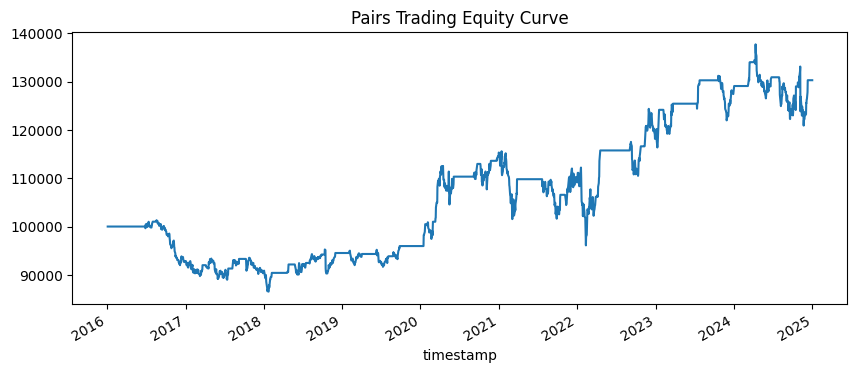

In [ ]:
# --- Strategy 2: Pairs Trading (Calm Regime) ---
# Vectorized Backtest Implementation

print(f"Running Pairs Trading Backtest for {PAIR_SYMBOLS}...")

# Fetch Data
pair_data = data_handler.get_historical_bars(list(PAIR_SYMBOLS), '1D', START_DATE, END_DATE)
df_a = pair_data[PAIR_SYMBOLS[0]]
df_b = pair_data[PAIR_SYMBOLS[1]]

# Align Data
df_pair = pd.DataFrame({'price_a': df_a['close'], 'price_b': df_b['close']}).dropna()

# Calculate Spread and Z-Score
df_pair['spread'] = df_pair['price_a'] - HEDGE_RATIO * df_pair['price_b']
df_pair['mean'] = df_pair['spread'].rolling(window=60).mean()
df_pair['std'] = df_pair['spread'].rolling(window=60).std()
df_pair['z_score'] = (df_pair['spread'] - df_pair['mean']) / df_pair['std']

# Generate Signals
entry_threshold = 2.0
exit_threshold = 0.0
df_pair['position'] = 0 # 1 for Long Spread, -1 for Short Spread

# Vectorized Signal Logic (Simplified)
# Note: Real backtest needs loop for stateful logic (holding until exit). 
# Here we use a simple loop for accuracy.
position = 0
positions = []
for z in df_pair['z_score']:
    if position == 0:
        if z > entry_threshold: position = -1 # Short Spread
        elif z < -entry_threshold: position = 1 # Long Spread
    elif position == -1:
        if z < exit_threshold: position = 0 # Exit Short
    elif position == 1:
        if z > -exit_threshold: position = 0 # Exit Long
    positions.append(position)

df_pair['position'] = positions

# Calculate Returns
# Spread Return approx = Position * Change in Spread
# (This is a simplification. Real return depends on capital allocation to legs)
# Assuming $10k capital, allocated 50/50 roughly.
# Let's calculate raw PnL per unit of spread and scale it.
df_pair['spread_change'] = df_pair['spread'].diff()
df_pair['pnl'] = df_pair['position'].shift(1) * df_pair['spread_change'] * 100 # Assuming 100 shares base
df_pair['equity'] = INITIAL_CAPITAL + df_pair['pnl'].cumsum().fillna(0)
df_pair['daily_return'] = df_pair['equity'].pct_change().fillna(0)

print(f"Pairs Trade Total Return: {((df_pair['equity'].iloc[-1] / INITIAL_CAPITAL) - 1) * 100:.2f}%")

# Plot Pairs Equity
plt.figure(figsize=(10, 4))
df_pair['equity'].plot()
plt.title("Pairs Trading Equity Curve")
plt.show()

--- System Performance ---
Total Return: 68.66%
Buy & Hold SPY: 208.82%
Sharpe Ratio: 0.89


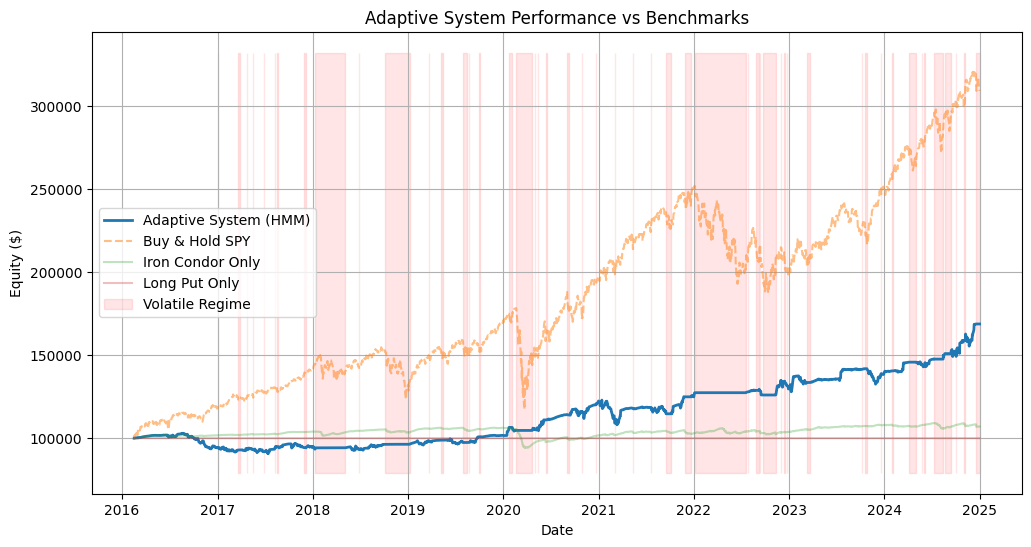

In [ ]:
# --- System Combination ---

# Align all series to the same index (dates)
common_index = spy_data.index.intersection(df_pair.index).intersection(ic_equity.index).intersection(sector_equity.index)

system_df = pd.DataFrame(index=common_index)
system_df['regime'] = regime_series.reindex(common_index).fillna(0) # Default to Calm
system_df['ic_ret'] = ic_equity['daily_return'].reindex(common_index).fillna(0)
system_df['lp_ret'] = lp_equity['daily_return'].reindex(common_index).fillna(0)
system_df['pairs_ret'] = df_pair['daily_return'].reindex(common_index).fillna(0)
system_df['sector_ret'] = sector_equity['daily_return'].reindex(common_index).fillna(0)

# Allocation Weights (Hypothetical)
# We have $100k total.
# Sector Momentum: $30k (30%)
# Options/Pairs: $70k (70%)
W_SECTOR = 0.30
W_ACTIVE = 0.70

# Apply Regime Switching Logic for the "Active" Portion
# Regime 0 (Calm): Iron Condor + Pairs
# Regime 1 (Volatile): Long Put
system_df['active_ret'] = np.where(
    system_df['regime'] == 0, 
    system_df['ic_ret'] + system_df['pairs_ret'], 
    system_df['lp_ret']
)

# Total System Return = Weighted Sum
# Note: The individual strategy returns are already based on their own capital base.
# If we allocate 30% to Sector, we get 30% of its return impact on the total portfolio.
system_df['system_ret'] = (W_SECTOR * system_df['sector_ret']) + (W_ACTIVE * system_df['active_ret'])

# Calculate Cumulative Equity
system_df['system_equity'] = INITIAL_CAPITAL * (1 + system_df['system_ret']).cumprod()
system_df['buy_hold_equity'] = INITIAL_CAPITAL * (spy_data['close'].reindex(common_index) / spy_data['close'].reindex(common_index).iloc[0])

# Performance Metrics
total_return = (system_df['system_equity'].iloc[-1] / INITIAL_CAPITAL - 1) * 100
buy_hold_return = (system_df['buy_hold_equity'].iloc[-1] / INITIAL_CAPITAL - 1) * 100
sharpe = system_df['system_ret'].mean() / system_df['system_ret'].std() * np.sqrt(252)

print(f"--- System Performance ---")
print(f"Total Return: {total_return:.2f}%")
print(f"Buy & Hold SPY: {buy_hold_return:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(system_df.index, system_df['system_equity'], label='Adaptive System (HMM + Sector)', linewidth=2)
plt.plot(system_df.index, system_df['buy_hold_equity'], label='Buy & Hold SPY', alpha=0.5, linestyle='--')
plt.plot(ic_equity.index, ic_equity['equity'], label='Iron Condor Only', alpha=0.3)
plt.plot(sector_equity.index, sector_equity['equity'], label='Sector Mom Only', alpha=0.3)

# Highlight Regimes on Equity Curve
y_min, y_max = plt.ylim()
plt.fill_between(system_df.index, y_min, y_max, where=(system_df['regime']==1), color='red', alpha=0.1, label='Volatile Regime')

plt.title("Adaptive System Performance vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.legend()
plt.grid(True)
plt.show()